In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("titanic_data.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df['Age'] = df["Age"].fillna(df["Age"].mean())

In [7]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [9]:
df['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [10]:
df.drop(columns=["PassengerId","Name","Ticket","Cabin"], inplace=True)

In [11]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


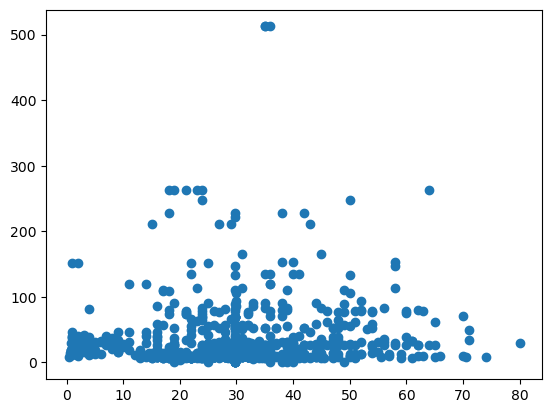

In [12]:
plt.scatter(df["Age"], df["Fare"])

<Axes: >

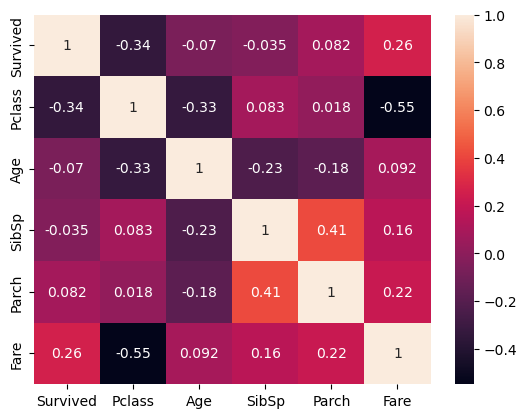

In [13]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex']).astype('int')
df['Embarked'] = le.fit_transform(df['Embarked']).astype('int')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int32  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int32  
dtypes: float64(2), int32(2), int64(4)
memory usage: 48.9 KB


<Axes: xlabel='Age', ylabel='Fare'>

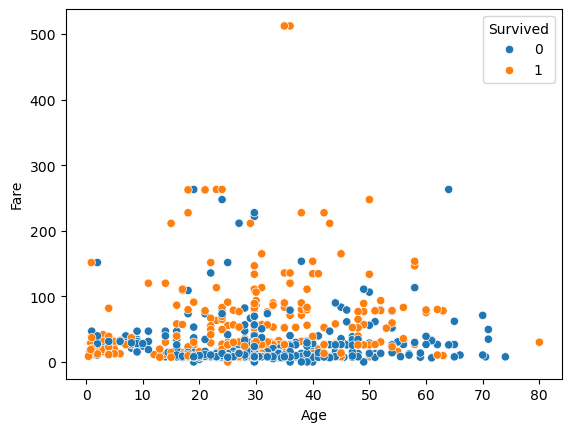

In [17]:
sns.scatterplot(x=df["Age"], y=df["Fare"], hue=df["Survived"])

In [18]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

In [19]:
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [21]:
X_train.shape,X_test.shape, y_train.shape, y_test.shape

((712, 7), (179, 7), (712,), (179,))

In [22]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

In [23]:
model.fit(X_train, y_train)

LogisticRegression()

In [24]:
y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.8100558659217877
Confusion Matrix:
 [[90 15]
 [19 55]]
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_test_scaled

array([[ 0.81303367,  0.7243102 ,  0.01239022, ...,  0.78470001,
        -0.33390078, -2.01983093],
       [-0.40055118,  0.7243102 ,  0.11257046, ..., -0.47934164,
        -0.42528387,  0.55744438],
       [ 0.81303367,  0.7243102 , -0.73453348, ..., -0.47934164,
        -0.47486697,  0.55744438],
       ...,
       [ 0.81303367, -1.38062393,  0.6516366 , ...,  5.8408666 ,
        -0.02308312,  0.55744438],
       [-0.40055118, -1.38062393, -0.96556183, ..., -0.47934164,
        -0.42528387,  0.55744438],
       [ 0.81303367, -1.38062393, -1.96668467, ...,  0.78470001,
        -0.30589933,  0.55744438]])

In [27]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=3)

In [28]:
knn_model.fit(X_train_scaled,y_train)

KNeighborsClassifier(n_neighbors=3)

In [29]:
y_pred_knn = knn_model.predict(X_test_scaled)

In [30]:
print("Accuracy Score :- ",accuracy_score(y_pred_knn,y_test))
print("Confusion matrix :- \n",confusion_matrix(y_pred_knn,y_test))
print("Classification Report :-\n",classification_report(y_pred_knn,y_test))

Accuracy Score :-  0.7932960893854749
Confusion matrix :- 
 [[88 20]
 [17 54]]
Classification Report :-
               precision    recall  f1-score   support

           0       0.84      0.81      0.83       108
           1       0.73      0.76      0.74        71

    accuracy                           0.79       179
   macro avg       0.78      0.79      0.79       179
weighted avg       0.80      0.79      0.79       179



<Axes: xlabel='Age', ylabel='Count'>

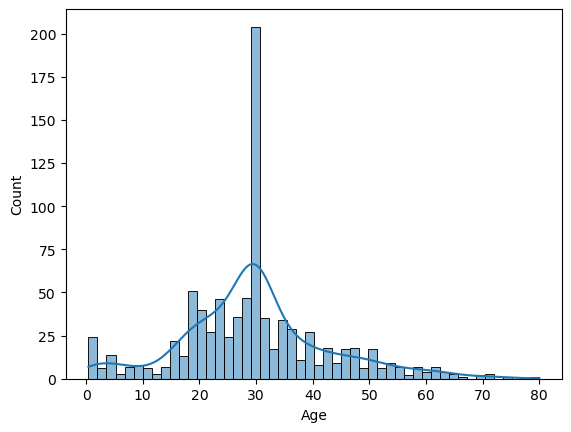

In [31]:
sns.histplot(df["Age"], bins=50, kde=True)

In [32]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()

In [33]:
nb_model.fit(X_train,y_train)

GaussianNB()

In [34]:
y_pred_nb = nb_model.predict(X_test)

In [35]:
print("Accuracy Score :- ",accuracy_score(y_pred_nb,y_test))
print("Confusion matrix :- \n",confusion_matrix(y_pred_nb,y_test))
print("Classification Report :-\n",classification_report(y_pred_nb,y_test))

Accuracy Score :-  0.776536312849162
Confusion matrix :- 
 [[82 17]
 [23 57]]
Classification Report :-
               precision    recall  f1-score   support

           0       0.78      0.83      0.80        99
           1       0.77      0.71      0.74        80

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [36]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42)

model_dt.fit(X_train_scaled,y_train)

DecisionTreeClassifier(random_state=42)

In [37]:
y_pred_dt = model_dt.predict(X_test_scaled)

In [38]:
print("Accuracy Score :- ",accuracy_score(y_pred_nb,y_test))
print("Confusion matrix :- \n",confusion_matrix(y_pred_nb,y_test))
print("Classification Report :-\n",classification_report(y_pred_nb,y_test))

Accuracy Score :-  0.776536312849162
Confusion matrix :- 
 [[82 17]
 [23 57]]
Classification Report :-
               precision    recall  f1-score   support

           0       0.78      0.83      0.80        99
           1       0.77      0.71      0.74        80

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [39]:
from sklearn.svm import SVC

model_svm = SVC(kernel='rbf')

model_svm.fit(X_train_scaled, y_train)

SVC()

In [40]:
y_pred_svm =   model_svm.predict(X_test_scaled)

In [41]:
print("Accuracy Score :- ",accuracy_score(y_pred_svm,y_test))
print("Confusion matrix :- \n",confusion_matrix(y_pred_svm,y_test))
print("Classification Report :-\n",classification_report(y_pred_svm,y_test))

Accuracy Score :-  0.8156424581005587
Confusion matrix :- 
 [[93 21]
 [12 53]]
Classification Report :-
               precision    recall  f1-score   support

           0       0.89      0.82      0.85       114
           1       0.72      0.82      0.76        65

    accuracy                           0.82       179
   macro avg       0.80      0.82      0.81       179
weighted avg       0.82      0.82      0.82       179



In [42]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


In [43]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [45]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model_svm,X_scaled,y,cv=5,scoring='accuracy')

In [46]:
scores

array([0.83240223, 0.82022472, 0.81460674, 0.80337079, 0.86516854])

In [47]:
print(scores.mean())

0.827154604230745


In [48]:
# grid search cv
# knn
# weights = ["uniform", "distance"]
# metric = ["euclidean", "manhattan", "minkowski"]

In [49]:
from sklearn.model_selection import GridSearchCV

classifier = GridSearchCV((model_svm),{
    'C': [1,10,20,30,40],
    'kernel': ['rbf', 'linear'],
    # 'gamma': ['scale', 'auto']
}, cv=5 , return_train_score=False)

In [50]:
classifier.fit(X,y)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [1, 10, 20, 30, 40], 'kernel': ['rbf', 'linear']})

In [51]:
classifier.cv_results_

{'mean_fit_time': array([4.40001965e-02, 8.58459663e+00, 3.91975880e-02, 3.15560109e+01,
        5.04008770e-02, 5.72121340e+01, 4.32220936e-02, 8.29426499e+01,
        5.14648914e-02, 8.18240526e+01]),
 'std_fit_time': array([3.42804108e-02, 7.99034696e+00, 6.43160679e-03, 1.48191688e+01,
        1.40369567e-02, 1.68079144e+01, 2.25981024e-02, 1.98415699e+01,
        3.78162421e-03, 2.39349584e+01]),
 'mean_score_time': array([0.01840072, 0.00800204, 0.01800056, 0.00378566, 0.02820106,
        0.00519953, 0.01551356, 0.00850658, 0.02400074, 0.00622182]),
 'std_score_time': array([0.00796619, 0.00498351, 0.00109441, 0.00039453, 0.0098869 ,
        0.00292682, 0.0010826 , 0.00454401, 0.00356122, 0.00201289]),
 'param_C': masked_array(data=[1, 1, 10, 10, 20, 20, 30, 30, 40, 40],
              mask=[False, False, False, False, False, False, False, False,
                    False, False],
        fill_value='?',
             dtype=object),
 'param_kernel': masked_array(data=['rbf', 'linea

In [52]:
grid_search_df = pd.DataFrame(classifier.cv_results_)

In [53]:
grid_search_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.044000,0.034280,0.018401,0.007966,1,rbf,"{'C': 1, 'kernel': 'rbf'}",0.597765,0.713483,0.691011,0.685393,0.691011,0.675733,0.040160,10
1,8.584597,7.990347,0.008002,0.004984,1,linear,"{'C': 1, 'kernel': 'linear'}",0.804469,0.808989,0.786517,0.752809,0.786517,0.787860,0.019771,1
2,0.039198,0.006432,0.018001,0.001094,10,rbf,"{'C': 10, 'kernel': 'rbf'}",0.620112,0.730337,0.713483,0.730337,0.747191,0.708292,0.045360,9
3,31.556011,14.819169,0.003786,0.000395,10,linear,"{'C': 10, 'kernel': 'linear'}",0.804469,0.808989,0.786517,0.752809,0.786517,0.787860,0.019771,1
4,0.050401,0.014037,0.028201,0.009887,20,rbf,"{'C': 20, 'kernel': 'rbf'}",0.636872,0.735955,0.724719,0.735955,0.769663,0.720633,0.044511,8
5,57.212134,16.807914,0.005200,0.002927,20,linear,"{'C': 20, 'kernel': 'linear'}",0.804469,0.808989,0.786517,0.752809,0.786517,0.787860,0.019771,1
6,0.043222,0.022598,0.015514,0.001083,30,rbf,"{'C': 30, 'kernel': 'rbf'}",0.642458,0.775281,0.741573,0.764045,0.797753,0.744222,0.054011,7
7,82.942650,19.841570,0.008507,0.004544,30,linear,"{'C': 30, 'kernel': 'linear'}",0.804469,0.808989,0.786517,0.752809,0.786517,0.787860,0.019771,1
8,0.051465,0.003782,0.024001,0.003561,40,rbf,"{'C': 40, 'kernel': 'rbf'}",0.642458,0.780899,0.780899,0.769663,0.831461,0.761076,0.063062,6
9,81.824053,23.934958,0.006222,0.002013,40,linear,"{'C': 40, 'kernel': 'linear'}",0.804469,0.808989,0.786517,0.752809,0.786517,0.787860,0.019771,1
